In [72]:
#import library dan package yang dibutuhkan

import pandas as pd
import seaborn as sns
import numpy as np #untuk perhitungan saintifik
import matplotlib.pyplot as plt #untuk plotting
from sklearn.linear_model import LinearRegression #import library LinearRegression dari scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [73]:
# Dataset
data = pd.read_csv("C:\KULIAH\MATA KULIAH SEMESTER 5\PEMBELAJARAN MESIN\Tugas 1 Linear Regression\Housing.csv")
df = pd.DataFrame(data)

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [74]:
# 2️⃣ Bersihkan spasi di nama kolom
df.columns = df.columns.str.strip()

In [75]:
# 3️⃣ Ubah semua data kategorikal ke numerik (otomatis)
df = pd.get_dummies(df, drop_first=True)

In [77]:
# 4️⃣ Pisahkan X dan y
X = df.drop('price', axis=1)
y = df['price']

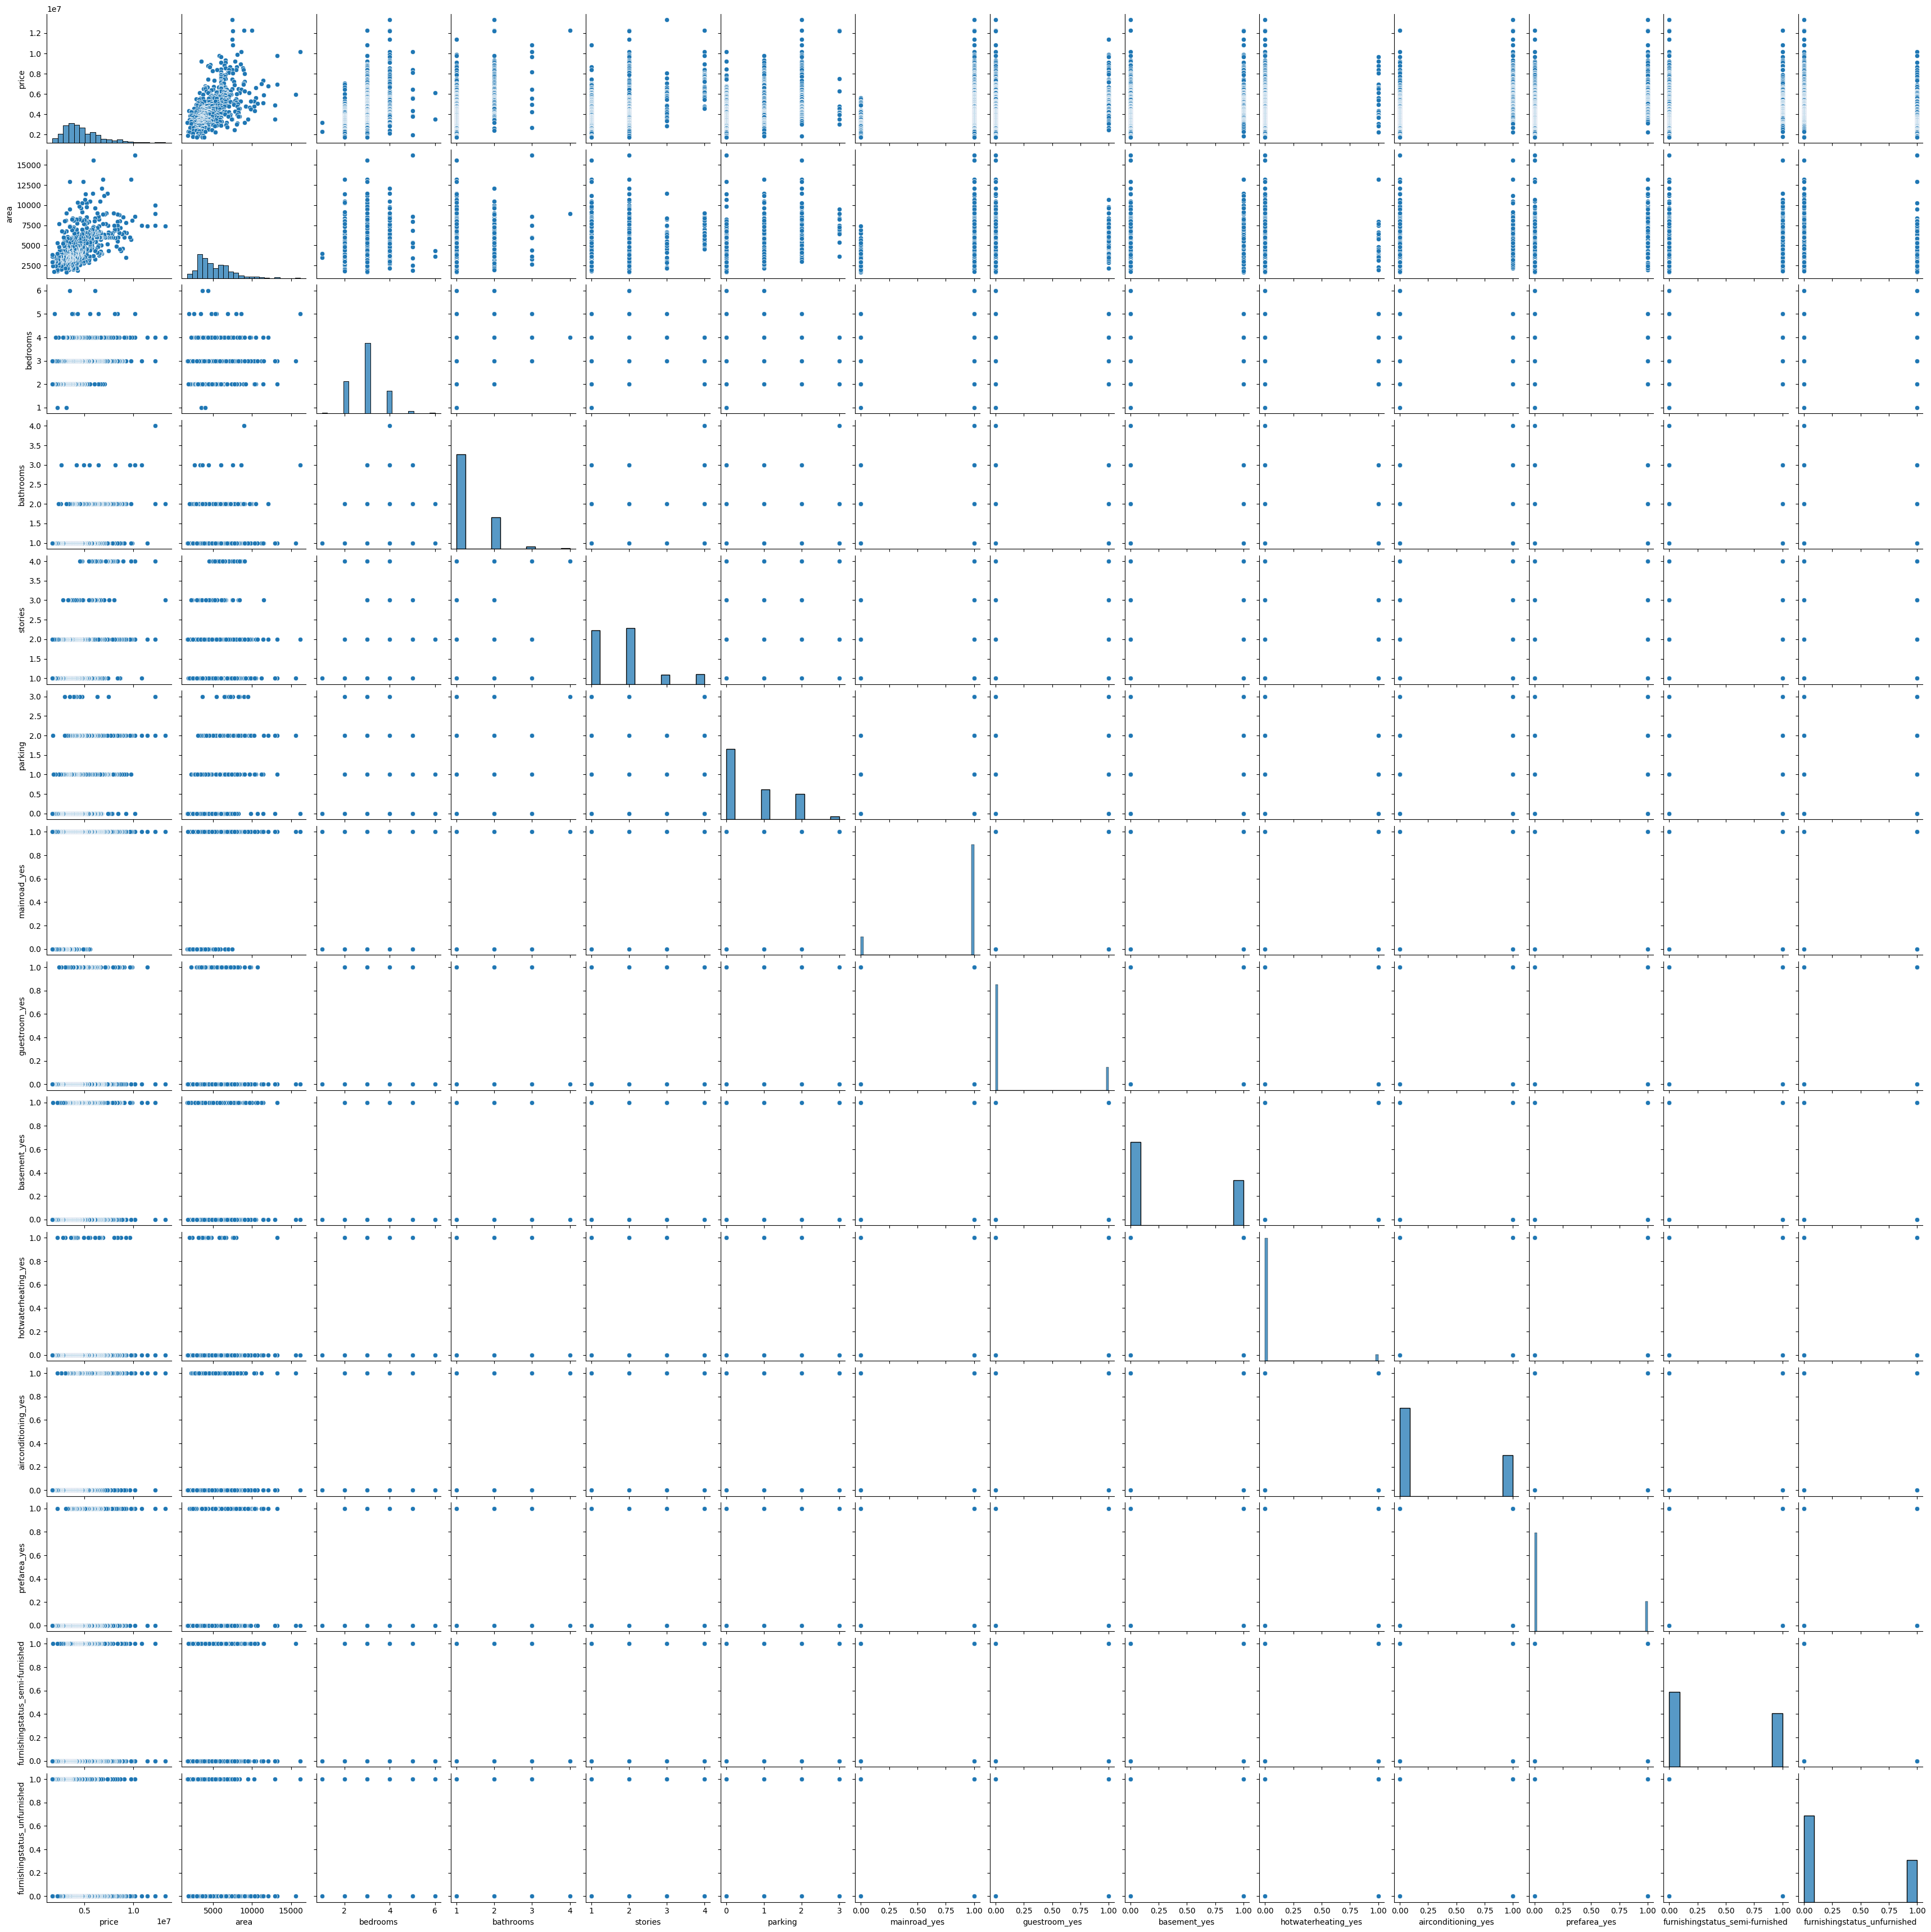

In [78]:
# Visualisasi hubungan antar variabel
sns.pairplot(df)
plt.show()

In [79]:
# Membagi data menjadi data latih (training) dan data uji (testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [80]:
# Membuat instance dari model
model = LinearRegression()
# Melatih model menggunakan data training
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
# Melakukan prediksi pada data test
predictions = model.predict(X_test)

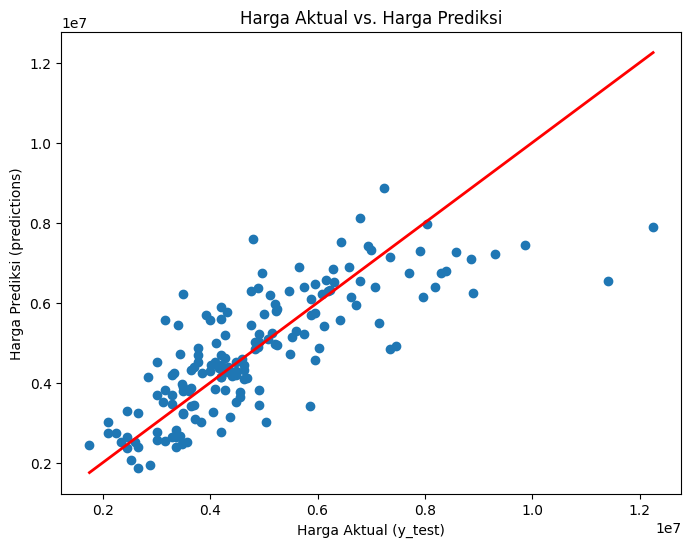

In [82]:
# Visualisasi hasil prediksi vs nilai aktual
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel("Harga Aktual (y_test)")
plt.ylabel("Harga Prediksi (predictions)")
plt.title("Harga Aktual vs. Harga Prediksi")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2) # Garis ideal
plt.show()

In [84]:
# Evaluasi performa model
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

Mean Absolute Error (MAE): 817762.9532006816
Mean Squared Error (MSE): 1264406165048.487
Root Mean Squared Error (RMSE): 1124458.1650948545
R-squared (R2): 0.612515556040494


In [85]:
# Menampilkan intersep dan koefisien
print(f"Intercept: {model.intercept_}")
print(pd.DataFrame(model.coef_, X.columns, columns=['Coefficient']))

Intercept: -54794.77563390788
                                  Coefficient
area                             2.658747e+02
bedrooms                         9.863324e+04
bathrooms                        9.549813e+05
stories                          4.672404e+05
parking                          2.923275e+05
mainroad_yes                     4.203070e+05
guestroom_yes                    8.280785e+04
basement_yes                     4.094060e+05
hotwaterheating_yes              1.002453e+06
airconditioning_yes              8.371028e+05
prefarea_yes                     7.105399e+05
furnishingstatus_semi-furnished  2.484153e+04
furnishingstatus_unfurnished    -4.392504e+05


In [86]:
import pickle

# Simpan model yang sudah dilatih
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)